# <a id='toc1_'></a>[<span style='color:yellow;'>Color Space Conversion</span>](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style='color:yellow;'>Color Space Conversion</span>](#toc1_)    
- [Step 1: Import Required Libraries](#toc2_)    
- [Step 2: Load and Prepare Image](#toc3_)    
- [Step 3: RGB to HSV Conversion](#toc4_)    
- [Step 4: RGB to HSL Conversion](#toc5_)    
- [Step 5: Key Takeaways](#toc6_)    
  - [Why Color Spaces Matter](#toc6_1_)    
  - [When to Use HSV vs. HSL](#toc6_2_)    
  - [Tools for Further Exploration](#toc6_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import Required Libraries](#toc0_)
We'll use optimized conversion functions from `OpenCV (cv2)` for faster color space transformations.

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# OpenCV (Open Source Computer Vision Library) 
# was developed to enable real-time computer vision. 
# The cv2 module is its Python interface, 
# bridging efficient C++ backend implementations 
# with Python's ease of use.
import cv2  # For optimized color space conversions

In [8]:
# Set seaborn style
sns.set_style("whitegrid")

In [9]:
print("Libraries imported successfully! \nUsing OpenCV's built-in color conversion functions for efficiency.")

Libraries imported successfully! 
Using OpenCV's built-in color conversion functions for efficiency.


# <a id='toc3_'></a>[Step 2: Load and Prepare Image](#toc0_)
We'll use a built-in image and ensure it's properly formatted for OpenCV.

In [10]:
# Load a sample image from matplotlib 
# and convert to 8-bit RGB
# from matplotlib.cbook import get_sample_data
img_path = 'lena.png'
img = plt.imread(img_path)

In [11]:
# Resize to max 256x256
max_size = 256
h, w = img.shape[:2]
if h > max_size or w > max_size:
    scale = max_size / max(h, w)
    img = cv2.resize(img, (int(w*scale), int(h*scale)))

In [12]:
# Convert from [0,1] float to [0,255] uint8 for OpenCV
img_uint8 = (img * 255).astype(np.uint8)

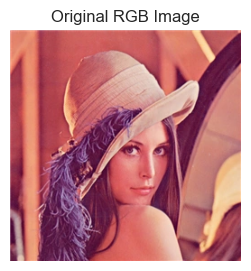

In [13]:
# Display original image
plt.figure(figsize=(4, 3))
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

* The "`Lena`" image—featuring `Lena Söderberg`—is a iconic test image in image processing, computer vision, and graphics.

* Originating from a 1972 Playboy centerfold, it was popularized by 1970s researchers for testing algorithms (compression, filtering, transformations) 

* thanks to its balanced mix of skin tones, fine details (hair/facial features), textures (bikini fabric), and varied brightness/contrast. 

* Long a de facto standard in academia and tools like OpenCV, it later sparked debates about gender representation, prompting calls for more diverse test images.

In [14]:
print(f"Image shape: {img.shape} (height x width x channels)")
print("Image values normalized between 0 and 1")

Image shape: (256, 256, 4) (height x width x channels)
Image values normalized between 0 and 1


# <a id='toc4_'></a>[Step 3: RGB to HSV Conversion](#toc0_)
* OpenCV's cvtColor function provides highly optimized color space conversions.
* The `HSV` (**Hue, Saturation, Value**) color space corresponds better to how people experience color than the RGB color space does. 
![](hsvcone.gif)<br>
https://www.mathworks.com/help/images/understanding-color-spaces-and-color-space-conversion.html

In [15]:
# Convert RGB to HSV using OpenCV 
# (note: OpenCV uses BGR format internally)
hsv_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)

In [16]:
# Normalize channels for visualization
h_norm = hsv_img[:, :, 0] / 179.0  # HSV in OpenCV uses H:0-179
s_norm = hsv_img[:, :, 1] / 255.0
v_norm = hsv_img[:, :, 2] / 255.0

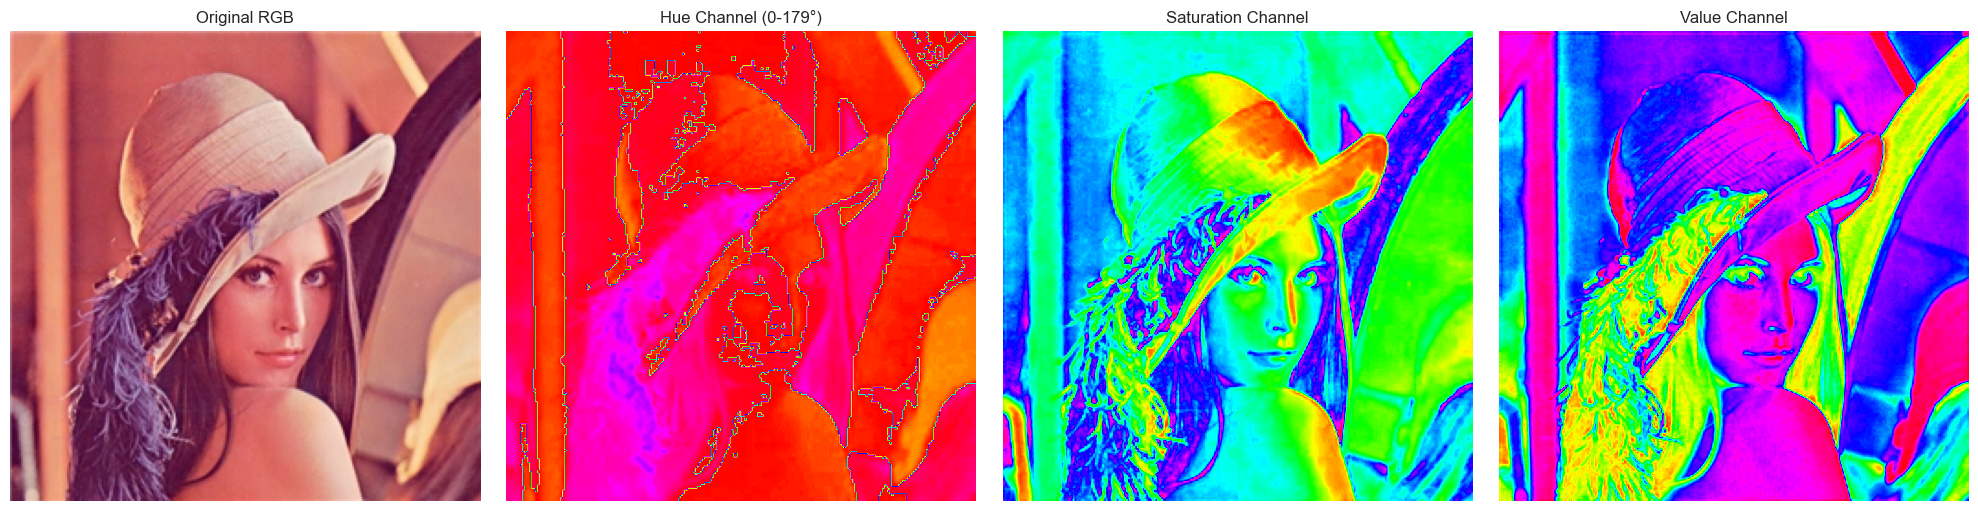

In [28]:
# Visualize HSV channels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(h_norm, cmap="hsv")
axes[1].set_title("Hue Channel (0-179°)")
axes[1].axis("off")

axes[2].imshow(s_norm, cmap="hsv")
axes[2].set_title("Saturation Channel")
axes[2].axis("off")

axes[3].imshow(v_norm, cmap="hsv")
axes[3].set_title("Value Channel")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [18]:
print("HSV conversion performed using OpenCV's optimized COLOR_RGB2HSV function")
print("OpenCV HSV ranges: H[0-179], S[0-255], V[0-255]")

HSV conversion performed using OpenCV's optimized COLOR_RGB2HSV function
OpenCV HSV ranges: H[0-179], S[0-255], V[0-255]


# <a id='toc5_'></a>[Step 4: RGB to HSL Conversion](#toc0_)
OpenCV also supports HSL (Hue, Saturation, Lightness) conversion.

In [19]:
# Convert RGB to HSL using OpenCV
hls_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HLS)

1. `Implementation legacy`: Early `computer vision` systems used "HLS" as an alternative label for the `HSL` color space, emphasizing the processing order $$(Hue → Lightness → Saturation)$$
1. `API consistency`: OpenCV follows a component-order convention (Hue first, then secondary attributes) like with HSV, leading to "`HLS`" (Hue, Lightness, Saturation) for alignment.

In [20]:
# Normalize channels for visualization
h_hls_norm = hls_img[:, :, 0] / 179.0
l_norm = hls_img[:, :, 1] / 255.0
s_hls_norm = hls_img[:, :, 2] / 255.0

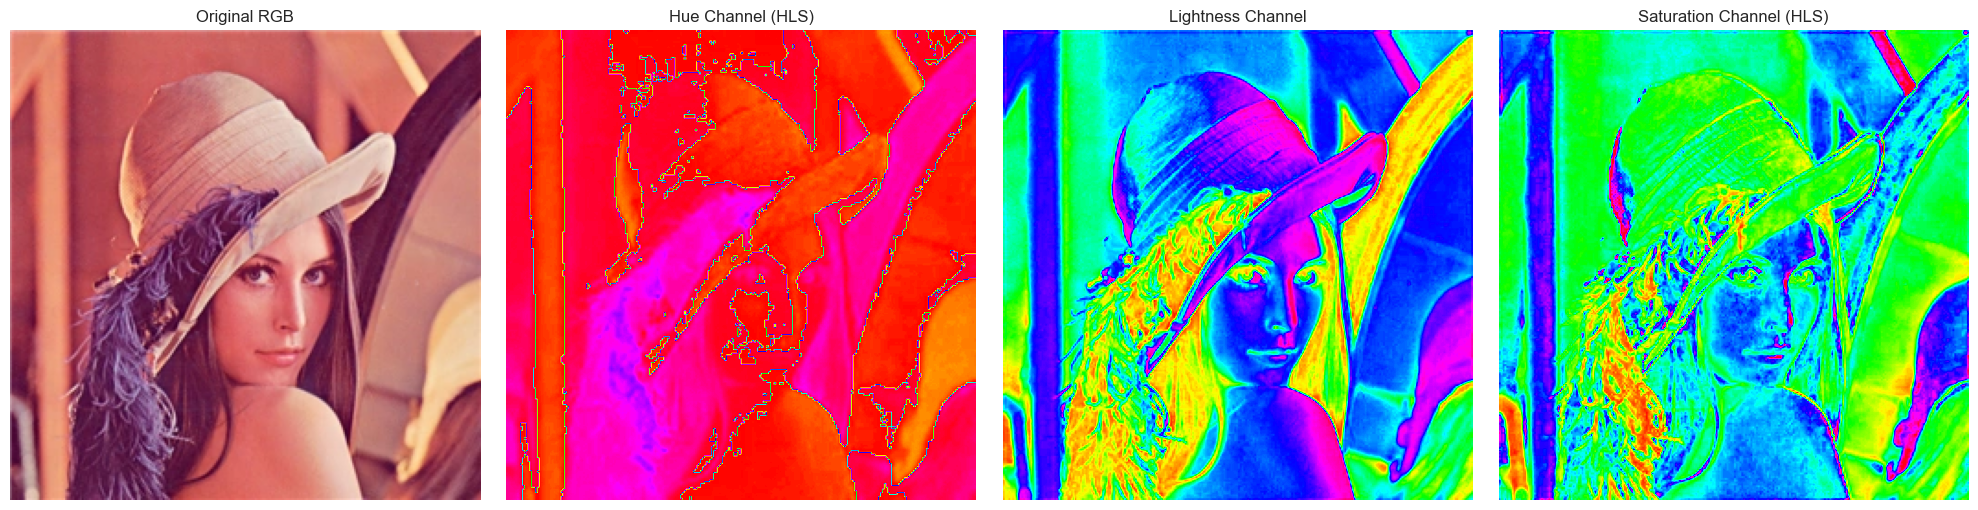

In [29]:
# Visualize HLS channels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(h_hls_norm, cmap="hsv")
axes[1].set_title("Hue Channel (HLS)")
axes[1].axis("off")

axes[2].imshow(l_norm, cmap="hsv")
axes[2].set_title("Lightness Channel")
axes[2].axis("off")

axes[3].imshow(s_hls_norm, cmap="hsv")
axes[3].set_title("Saturation Channel (HLS)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [22]:
print("HLS conversion performed \n" \
"using OpenCV's optimized COLOR_RGB2HLS function")

HLS conversion performed 
using OpenCV's optimized COLOR_RGB2HLS function


# <a id='toc6_'></a>[Step 5: Key Takeaways](#toc0_)

## <a id='toc6_1_'></a>[Why Color Spaces Matter](#toc0_)
* RGB: Natural for digital displays (uses red, green, blue light), but mixes color and brightness information.
* HSV/HSL: Separate color (hue) from brightness (value/lightness) and intensity (saturation), making them easier for:
    * Color-based image segmentation (e.g., detecting red objects in a scene)
    * Adjusting brightness/color without affecting other properties
    * Intuitive color manipulation (e.g., photo editing tools)

## <a id='toc6_2_'></a>[When to Use HSV vs. HSL](#toc0_)
* HSV is often preferred for:
    * Computer vision tasks (e.g., object detection by color)
    * Lighting control systems
* HSL is often preferred for:
    * Graphic design and web development
    * Applications where human perception of lightness is important

## <a id='toc6_3_'></a>[Tools for Further Exploration](#toc0_)
* OpenCV's cvtColor supports many other color spaces (e.g., LAB, YCrCb) – try replacing COLOR_RGB2HSV with other constants like COLOR_RGB2LAB.
* For simple adjustments, you can modify HSV/HSL channels directly (e.g., increase value to make an image brighter) and convert back to RGB.

In [23]:
# Example: Simple brightness adjustment using HSV
hsv_bright = hsv_img.copy()
hsv_bright[:, :, 2] = np.clip(hsv_bright[:, :, 2] * 1.5, 0, 255).astype(np.uint8)  # Increase value by 50%
rgb_bright = cv2.cvtColor(hsv_bright, cv2.COLOR_HSV2RGB) / 255.0

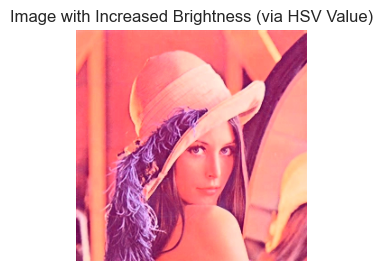

In [24]:
# Display result
plt.figure(figsize=(4, 3))
plt.imshow(rgb_bright)
plt.title("Image with Increased Brightness (via HSV Value)")
plt.axis("off")
plt.show()

In [25]:
print("This example shows how easy \nit is to adjust brightness using HSV - \nwe only modified the Value channel!")

This example shows how easy 
it is to adjust brightness using HSV - 
we only modified the Value channel!
